# Continuous Networked Koopman Operator

This notebook combines **irregular sampling** (notebook 12) with **networked
graph coupling** (notebook 18) via

```python
GraphKoopmanModel(..., koopman="graph", dynamics_mode="continuous")
```

which builds a `ContinuousGraphKoopmanOperator` (checkpoint kind
`continuous_graph`). We fit an irregularly subsampled ring-diffusion series,
contrast holdout `predict_at` RMSE against a continuous per-node baseline,
inspect the effective $N\cdot d$ generator spectrum, and state the dense
matrix-exponential cost caveat.


## Setup


In [1]:
import warnings

from tqdm.std import TqdmWarning

warnings.filterwarnings("ignore", category=TqdmWarning)

import importlib.metadata
import os
import random
import time

import matplotlib

if os.environ.get("PYTEST_CURRENT_TEST") or os.environ.get("CI"):
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch_geometric.data import Data

from koopman_graph import GNNDecoder, GNNEncoder, GraphKoopmanModel
from koopman_graph.data import GraphSnapshotSequence
from koopman_graph.datasets.dynamics import laplacian_diffusion_rollout
from koopman_graph.datasets.topology import ring_edge_index
from koopman_graph.operators.continuous_graph import ContinuousGraphKoopmanOperator

IS_TEST = bool(
    os.environ.get("PYTEST_CURRENT_TEST")
    or os.environ.get("CI")
    or os.environ.get("IS_TEST")
)
SEED = 34
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

N_NODES = 6 if IS_TEST else 12
IN_CHANNELS = 1
LATENT_DIM = 2 if IS_TEST else 4
EPOCHS = 3 if IS_TEST else 40
FINE_STEPS = 40 if IS_TEST else 120
FINE_DT = 0.05
N_SAMPLES = 16 if IS_TEST else 36
TRAIN_FRAC = 0.7
KG_VERSION = importlib.metadata.version("koopman-graph")
print(
    f"koopman-graph=={KG_VERSION}  IS_TEST={IS_TEST}  "
    f"N={N_NODES}  d={LATENT_DIM}  samples={N_SAMPLES}"
)


koopman-graph==0.10.0  IS_TEST=False  N=12  d=4  samples=36


## Motivation and background

Notebook 12 learns a **node-decoupled** continuous generator under irregular
$\Delta t$. Notebook 18 uses a **discrete** networked operator

$$
K_{\mathrm{eff}} = I \otimes K_{\mathrm{self}} + \hat{A} \otimes K_{\mathrm{nbr}}.
$$

Here $\hat{A}$ is the symmetrically normalized adjacency. Related discrete
networked Koopman factorizations appear in Li et al. (2020) (compositional
relation blocks) and Mukherjee et al. (2022) (sparse agent-block operators);
this notebook uses the package's shared self/neighbor continuous factors, not a
reproduction of those control or multi-agent experiments.

The continuous networked peer integrates

$$
L_{\mathrm{eff}} = I_N \otimes L_{\mathrm{self}} + \hat{A} \otimes L_{\mathrm{nbr}},
\qquad
\mathrm{vec}(Z_{t+\Delta t}) = \exp(L_{\mathrm{eff}}\,\Delta t)\,\mathrm{vec}(Z_t).
$$

**Cost caveat:** the dense path builds an $N\cdot d$ matrix exponential each
advance. Prefer modest $N$, or `koopman_sparsity="block_diagonal"` (self-term
only — exact when $L_{\mathrm{nbr}}=0$).


## Irregularly sampled diffusion benchmark

Simulate fine-grid Laplacian diffusion on a ring, then subsample at irregular
timestamps (monotone). Chronological train / holdout split.


In [2]:
def irregular_indices(n_fine: int, n_keep: int, seed: int) -> np.ndarray:
    """Strictly increasing subsample indices including 0 and last."""
    rng = np.random.default_rng(seed)
    if n_keep < 2 or n_keep > n_fine:
        raise ValueError("n_keep must be in [2, n_fine]")
    mid = rng.choice(np.arange(1, n_fine - 1), size=n_keep - 2, replace=False)
    idx = np.sort(np.concatenate([[0], mid, [n_fine - 1]]))
    return idx.astype(int)


edge_index = ring_edge_index(N_NODES)
gen = torch.Generator().manual_seed(SEED)
fine = laplacian_diffusion_rollout(
    edge_index=edge_index,
    num_nodes=N_NODES,
    num_timesteps=FINE_STEPS,
    in_channels=IN_CHANNELS,
    diffusion_rate=0.35,
    decay_rate=0.995,
    noise_std=0.0,
    initial_state="random",
    dtype=torch.float32,
    generator=gen,
)
fine_times = torch.arange(FINE_STEPS, dtype=torch.float32) * FINE_DT
idx = irregular_indices(FINE_STEPS, N_SAMPLES, seed=SEED)
times = fine_times[idx]
snapshots = [
    Data(x=fine[i].clone(), edge_index=edge_index) for i in idx
]
sequence = GraphSnapshotSequence(snapshots, timestamps=times)

split = max(4, int(TRAIN_FRAC * sequence.num_timesteps))
# Leave at least 3 holdout frames for query_times.
split = min(split, sequence.num_timesteps - 3)
train_seq = sequence.slice(0, split)
holdout = sequence.slice(split - 1, sequence.num_timesteps)  # overlap origin
print(
    f"fine T={FINE_STEPS}  irregular n={sequence.num_timesteps}  "
    f"train={train_seq.num_timesteps}  holdout_frames={holdout.num_timesteps}"
)
print(
    f"Δt range on train: "
    f"{float((train_seq.timestamps[1:] - train_seq.timestamps[:-1]).min()):.3f} .. "
    f"{float((train_seq.timestamps[1:] - train_seq.timestamps[:-1]).max()):.3f}"
)


fine T=120  irregular n=36  train=25  holdout_frames=12
Δt range on train: 0.050 .. 0.600


## Minimal example: fit continuous networked model

`koopman="graph"` + `dynamics_mode="continuous"` → `ContinuousGraphKoopmanOperator`.


In [3]:
torch.manual_seed(SEED)
model = GraphKoopmanModel(
    encoder=GNNEncoder(IN_CHANNELS, 16, LATENT_DIM, num_layers=2),
    decoder=GNNDecoder(LATENT_DIM, 16, IN_CHANNELS, num_layers=2),
    latent_dim=LATENT_DIM,
    time_step=FINE_DT,
    dynamics_mode="continuous",
    koopman="graph",
    koopman_parameterization="dense",
)
assert isinstance(model.koopman, ContinuousGraphKoopmanOperator)
assert model.koopman_kind == "continuous_graph"
_ = model.fit(train_seq, epochs=EPOCHS, lr=1e-3)
print(
    f"fitted continuous_graph  epochs={EPOCHS}  "
    f"uses_continuous_graph={model.uses_continuous_graph_koopman}"
)


fitted continuous_graph  epochs=40  uses_continuous_graph=True


## Progressive deep dive: `predict_at`, per-node contrast, spectrum

Query absolute horizons from the holdout origin (relative to
`holdout.timestamps[0]`). Score the continuous networked model against a
**continuous per-node** baseline (`koopman="pernode"`, same encoder/decoder
width and epochs) on the same irregular holdout — the gap can go either way
on this teaching proxy. Spectrum uses the topology-coupled $L_{\mathrm{eff}}$
— not the self-term alone.


In [4]:
origin = holdout[0]
assert holdout.timestamps is not None
t0 = float(holdout.timestamps[0])
query_times = [float(holdout.timestamps[i] - t0) for i in range(1, holdout.num_timesteps)]
targets = [holdout[i].x for i in range(1, holdout.num_timesteps)]


def holdout_predict_at_rmse(m: GraphKoopmanModel) -> tuple[float, list[float]]:
    m.eval()
    with torch.no_grad():
        forecasts = m.predict_at(origin, query_times=query_times)
    errs = [
        float(torch.mean((pred.x - tgt) ** 2).sqrt().item())
        for pred, tgt in zip(forecasts, targets, strict=True)
    ]
    return float(np.mean(errs)), errs


rmse_graph, errs_graph = holdout_predict_at_rmse(model)
print(
    f"continuous_graph predict_at mean RMSE: {rmse_graph:.6f}  "
    f"(n={len(errs_graph)} queries)"
)
print(f"per-query RMSE (graph): {[round(e, 4) for e in errs_graph]}")

torch.manual_seed(SEED)
model_pernode = GraphKoopmanModel(
    encoder=GNNEncoder(IN_CHANNELS, 16, LATENT_DIM, num_layers=2),
    decoder=GNNDecoder(LATENT_DIM, 16, IN_CHANNELS, num_layers=2),
    latent_dim=LATENT_DIM,
    time_step=FINE_DT,
    dynamics_mode="continuous",
    koopman="pernode",
)
_ = model_pernode.fit(train_seq, epochs=EPOCHS, lr=1e-3)
rmse_pernode, errs_pernode = holdout_predict_at_rmse(model_pernode)
print(
    f"continuous_pernode predict_at mean RMSE: {rmse_pernode:.6f}  "
    f"(n={len(errs_pernode)} queries)"
)
print(
    f"mean RMSE gap (pernode - graph): {rmse_pernode - rmse_graph:+.6f}  "
    "(positive ⇒ networked generator lower error on this split)"
)

# Effective networked generator spectrum (requires topology).
spec = model.spectrum(edge_index=edge_index, num_nodes=N_NODES)
eig = spec.eigenvalues.detach().cpu()
max_re = float(eig.real.max()) if torch.is_complex(eig) else float(eig.max())
print(
    f"L_eff spectrum size={eig.numel()} (= N·d = {N_NODES * LATENT_DIM}); "
    f"max Re(λ)={max_re:.4f} (informational; dense ≠ Hurwitz certificate)"
)
self_max = float(model.koopman.max_real_part().item())
print(f"L_self max Re(λ)={self_max:.4f} (self-term only; not whole-network)")


continuous_graph predict_at mean RMSE: 0.013825  (n=11 queries)
per-query RMSE (graph): [0.0067, 0.0094, 0.0107, 0.0112, 0.0131, 0.0136, 0.0145, 0.0159, 0.0183, 0.0188, 0.0198]
continuous_pernode predict_at mean RMSE: 0.011937  (n=11 queries)
mean RMSE gap (pernode - graph): -0.001888  (positive ⇒ networked generator lower error on this split)
L_eff spectrum size=48 (= N·d = 48); max Re(λ)=0.0732 (informational; dense ≠ Hurwitz certificate)
L_self max Re(λ)=0.0466 (self-term only; not whole-network)


## Cost caveat: dense $N\cdot d$ exp vs block-diagonal approx

Time one dense advance vs `koopman_sparsity="block_diagonal"` on the **fitted**
$L_{\mathrm{self}}$ / $L_{\mathrm{nbr}}$ (teaching micro-benchmark — wall times
vary by machine). The advance RMSE gap shows what dropping neighbor coupling
changes for this fit.


In [5]:
torch.manual_seed(SEED)
z = torch.randn(N_NODES, LATENT_DIM)
delta = 0.2

assert isinstance(model.koopman, ContinuousGraphKoopmanOperator)
dense_op = ContinuousGraphKoopmanOperator(LATENT_DIM, sparsity="dense")
block_op = ContinuousGraphKoopmanOperator(LATENT_DIM, sparsity="block_diagonal")
# Structural comparison on the *fitted* factors (not random init).
dense_op.set_dense_matrices(
    model.koopman.L_self.detach().clone(),
    model.koopman.L_nbr.detach().clone(),
)
block_op.set_dense_matrices(
    model.koopman.L_self.detach().clone(),
    model.koopman.L_nbr.detach().clone(),
)


def _time_advance(op, repeats: int = 20 if IS_TEST else 50) -> float:
    _ = op.advance(z, delta, edge_index=edge_index)
    t0 = time.perf_counter()
    for _ in range(repeats):
        _ = op.advance(z, delta, edge_index=edge_index)
    return (time.perf_counter() - t0) / repeats


t_dense = _time_advance(dense_op)
t_block = _time_advance(block_op)
print(
    f"mean advance time — dense N·d exp: {t_dense * 1e3:.3f} ms  "
    f"block_diagonal (L_self only): {t_block * 1e3:.3f} ms"
)
print(
    f"N·d = {N_NODES * LATENT_DIM}; dense cost grows with (N·d)³ for "
    "matrix exp — prefer modest N or block_diagonal when neighbor coupling "
    "is weak / diagnostic only."
)
with torch.no_grad():
    z_d = dense_op.advance(z, delta, edge_index=edge_index)
    z_b = block_op.advance(z, delta, edge_index=edge_index)
gap = float(torch.mean((z_d - z_b) ** 2).sqrt().item())
print(f"dense vs block_diagonal advance RMSE gap (fitted L): {gap:.4f}")


mean advance time — dense N·d exp: 0.012 ms  block_diagonal (L_self only): 0.051 ms
N·d = 48; dense cost grows with (N·d)³ for matrix exp — prefer modest N or block_diagonal when neighbor coupling is weak / diagnostic only.
dense vs block_diagonal advance RMSE gap (fitted L): 0.0070


## Results

Left: irregular physical times with chronological train (blue) / holdout (red)
and the holdout origin (dashed). Right: sorted $\mathrm{Re}(\lambda)$ of the
fitted $L_{\mathrm{eff}}$ ($N\cdot d$ eigenvalues). Note the staircase from
repeated structure on the ring and that several modes have
$\mathrm{Re}(\lambda)>0$ — the spectrum plot is diagnostic, not a Hurwitz
certificate. Holdout `predict_at` mean RMSE for continuous graph vs continuous
per-node is printed above (and summarized under the figure); per-query graph
errors typically grow with horizon. On the default seed/split, per-node can
match or beat graph — read the signed gap rather than assuming networked wins.


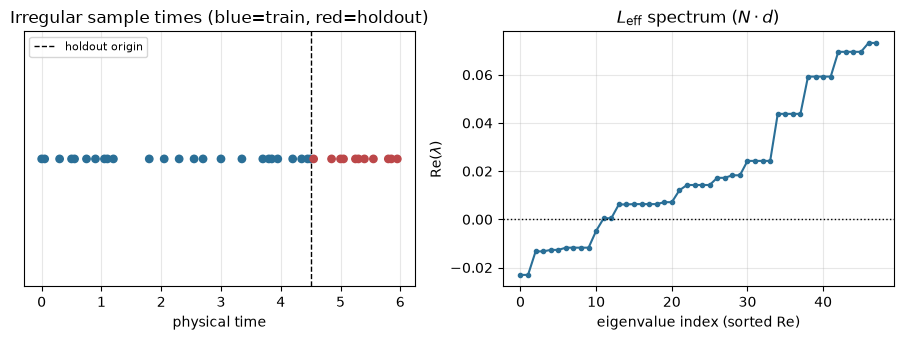

Summary — graph RMSE=0.013825  pernode RMSE=0.011937  gap(pernode-graph)=-0.001888


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3.5))

# Timeline of irregular samples
axes[0].scatter(
    times.numpy(),
    np.zeros_like(times.numpy()),
    s=28,
    c=["#2a6f97" if i < split else "#bc4749" for i in range(len(times))],
    zorder=3,
)
axes[0].axvline(float(times[split - 1]), color="k", ls="--", lw=1, label="holdout origin")
axes[0].set_xlabel("physical time")
axes[0].set_yticks([])
axes[0].set_title("Irregular sample times (blue=train, red=holdout)")
axes[0].legend(fontsize=8)
axes[0].grid(True, axis="x", alpha=0.3)

# Spectrum real parts
re = eig.real.numpy() if torch.is_complex(eig) else eig.numpy()
axes[1].plot(np.sort(re), marker="o", ms=3, color="#2a6f97")
axes[1].axhline(0.0, color="k", ls=":", lw=1)
axes[1].set_xlabel("eigenvalue index (sorted Re)")
axes[1].set_ylabel(r"$\mathrm{Re}(\lambda)$")
axes[1].set_title(r"$L_{\mathrm{eff}}$ spectrum ($N\cdot d$)")
axes[1].grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

print(
    f"Summary — graph RMSE={rmse_graph:.6f}  pernode RMSE={rmse_pernode:.6f}  "
    f"gap(pernode-graph)={rmse_pernode - rmse_graph:+.6f}"
)


## Interpretation

- Continuous + graph couples neighbor structure into the **generator**, then
  integrates with the true $\Delta t$. The holdout `predict_at` gap versus a
  continuous per-node fit is the coupling check on this split: a negative
  (pernode $-$ graph) gap means the networked generator did **not** improve
  RMSE here — topology in $L$ is available, not automatically helpful on this
  synthetic diffusion proxy.
- `predict_at(query_times=...)` is the off-grid forecast API (notebook 12);
  discrete networked models (notebook 18) reject irregular increments.
- Dense $L_{\mathrm{eff}}$ spectrum is size $N\cdot d$; positive
  $\mathrm{Re}(\lambda)$ can appear even when short-horizon forecasts look
  reasonable. Self-term `max_real_part` is **not** a whole-network Hurwitz
  certificate.
- At large $N$, budget the dense exp or switch to `block_diagonal`, knowing it
  drops neighbor coupling in the advance (fitted dense-vs-block gap above).
- Ground truth here is discrete Laplacian diffusion with labeled physical time —
  a teaching proxy for irregular timestamps, not a continuous PDE identification
  study.


## Takeaways

- **When to use:** `koopman="graph"` + `dynamics_mode="continuous"` (or
  `koopman="continuous_graph"`) when sampling is irregular **and** you need
  topology inside the latent generator; always compare `predict_at` RMSE to a
  continuous per-node baseline on a chronological holdout.
- **When not to:** if the per-node baseline matches or beats graph (as on this
  default seed/split), or if $N\cdot d$ matrix exponentials are too costly with
  weak neighbor coupling — prefer continuous per-node (notebook 12) or
  `koopman_sparsity="block_diagonal"`; for uniform discrete steps, use networked
  $K$ (notebook 18).
- **Gotchas:** $L_{\mathrm{eff}}$ spectra are informational (not stability
  certificates); dense-vs-block timing is machine-dependent; this demo is
  synthetic diffusion, not a traffic/SOTA claim.
- Cross-read notebook 12 (irregular continuous, no graph $L$) and notebook 18
  (discrete networked $K$).


## Further reading

- [API reference](https://koopmangraph.readthedocs.io/en/latest/api.html) —
  `ContinuousGraphKoopmanOperator`, `GraphKoopmanModel.predict_at`,
  `spectrum(edge_index=..., num_nodes=...)`
- [Architecture](https://koopmangraph.readthedocs.io/en/latest/architecture.html) —
  continuous-graph operator and dense $N\cdot d$ cost caveat
- Related notebooks:
  [`12_irregular_sampling_continuous_time.ipynb`](12_irregular_sampling_continuous_time.ipynb),
  [`18_networked_koopman_dynamic_topology.ipynb`](18_networked_koopman_dynamic_topology.ipynb)
- Citations (`paper.bib`): `Li2020CompositionalKoopman`, `Mukherjee2022`
